<a href="https://colab.research.google.com/github/Wahyunilamma/Data_Cleaning/blob/main/Cleaning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re

READ DATASET

In [ ]:
df=pd.read_csv('dirty_healthcare_dataset.csv', encoding='latin-1')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20200 entries, 0 to 20199
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient ID         18189 non-null  float64
 1   Age                13778 non-null  float64
 2   Gender             17295 non-null  object 
 3   Date of Birth      17292 non-null  object 
 4   Diagnosis Code     18314 non-null  object 
 5   Procedure Code     18292 non-null  object 
 6   Admission Date     18239 non-null  object 
 7   Discharge Date     18253 non-null  object 
 8   Length of Stay     18541 non-null  object 
 9   Primary Diagnosis  17284 non-null  object 
 10  Medication Name    17200 non-null  object 
 11  Dosage             17047 non-null  object 
 12  Treatment Date     18166 non-null  object 
 13  Provider ID        18225 non-null  object 
 14  Hospital Name      16815 non-null  object 
 15  Insurance Type     13725 non-null  object 
 16  Billing Amount     185

In [ ]:
#find out how many missing values per column. isna= is not available
print('\nMissing Values Per Column')
print(df.isna().sum())


Missing Values Per Column
Patient ID           2011
Age                  6422
Gender               2905
Date of Birth        2908
Diagnosis Code       1886
Procedure Code       1908
Admission Date       1961
Discharge Date       1947
Length of Stay       1659
Primary Diagnosis    2916
Medication Name      3000
Dosage               3153
Treatment Date       2034
Provider ID          1975
Hospital Name        3385
Insurance Type       6475
Billing Amount       1634
Blood Pressure       3141
Lab Test Results     2923
dtype: int64


In [ ]:
#Summary statistics for numerical colmns
print('\nNumerical Summary')
display(df.describe())


Numerical Summary


,Patient ID,Age
count,18189.000000,13778.000000
mean,5460.329760,61.213761
std,2596.878598,61.806240
min,1000.000000,-10.000000
25%,3202.000000,0.000000
50%,5436.000000,49.000000
75%,7712.000000,101.000000
max,9999.000000,200.000000


In [ ]:
#Unique values in categorical columns to spot inconsistencies
print('\nUnique Age:',df['Age'].unique()[:10])
print('\nUnique Genders:',df['Gender'].unique())
print('\nUnique Date of Birth:',df['Date of Birth'].unique())
print('\nUnique Diagnosis Code:',df['Diagnosis Code'].unique())
print('\nUnique Procedure Code:',df['Procedure Code'].unique())
print('\nUnique Admission Date:',df['Admission Date'].unique())
print('\nUnique Discharge Date:',df['Discharge Date'].unique())
print('\nUnique Length of Stay:',df['Length of Stay'].unique())
print('\nUnique Primary Diagnosis:',df['Primary Diagnosis'].unique())
print('\nUnique Medication Name:',df['Medication Name'].unique())
print('\nUnique Dosage:',df['Dosage'].unique())
print('\nUnique Treatment Date:',df['Treatment Date'].unique()[:10])
print('\nUnique Hospital Name:',df['Hospital Name'].unique())
print('\nUnique Insurance Type:',df['Insurance Type'].unique())
print('\nUnique Billing Amount:',df['Billing Amount'].unique())
print('\nUnique Blood Pressure:',df['Blood Pressure'].unique())
print('\nUnique Lab_Test_Results:',df['Lab Test Results'].unique())


Unique Age: [  nan  61.8 173.   49.4  93.   89.9 108.   92.5  -6.  188. ]

Unique Genders: ['mle' 'Girl' 'Fem' 'Male' 'F' 'Female' nan 'Other' 'Boy' 'M']

Unique Date of Birth: ['5/25/1958' '11/9/1951' '4/26/1980' ... '18-08-1911' '20-05-1975'
 '18-07-1901']

Unique Diagnosis Code: [nan 'D097' 'D093' 'D010' 'D515' 'D024' 'D032' 'D015' 'D052' 'D039' 'D044'
 'D036' 'D124' 'D079' 'D054' 'D084' 'D038' 'D030' 'D033' 'D082' 'D076'
 'D023' 'D073' 'D011' 'D099' 'D016' 'D045' 'D090' 'D020' 'D008' 'D022'
 'D071' 'D558' 'D080' 'D075' 'D040' 'D066' 'D046' 'D077' 'D007' 'D060'
 'D664' 'D070' 'D072' 'D001' 'D861' 'D103' 'D018' 'D053' 'D027' 'D085'
 'D029' 'D059' 'D058' 'D041' 'D009' 'D051' 'D057' 'D065' 'D391' 'D004'
 'D916' 'D092' 'D031' 'D177' 'D088' 'D222' 'D003' 'D089' 'D013' 'D078'
 'D087' 'D277' 'D063' 'D069' 'D094' 'D042' 'D083' 'D056' 'D086' 'D019'
 'D047' 'D025' 'D005' 'D923' 'D034' 'D062' 'D081' 'D064' 'D100' 'D014'
 'D049' 'D026' 'D271' 'D006' 'D028' 'D021' 'D585' 'D035' 'D055' 'D096'
 '

In [ ]:
#check duplicates
print('\nNumber of Duplicates Rows;')
print(df.duplicated().sum())


Number of Duplicates Rows;
200


In [ ]:
#Handle missing categorical values
categorical_cols=['Patient ID', 'Gender','Date of Birth', 'Diagnosis Code', 'Procedure Code', 'Admission Date',
                  'Discharge Date', 'Primary Diagnosis', 'Medication Name', 'Dosage', 'Treatment Date',
                  'Provider ID', 'Hospital Name', 'Insurance Type', 'Lab Test Results']
for col in categorical_cols:
    df[col]=df[col].fillna('Unknown')

#Handle missing categorical values
print('\nMissing Values After Categorical Imputation:')
print(df.isna().sum())


Missing Values After Categorical Imputation:
Patient ID              0
Age                  6422
Gender                  0
Date of Birth           0
Diagnosis Code          0
Procedure Code          0
Admission Date          0
Discharge Date          0
Length of Stay       1659
Primary Diagnosis       0
Medication Name         0
Dosage                  0
Treatment Date          0
Provider ID             0
Hospital Name           0
Insurance Type          0
Billing Amount       1634
Blood Pressure       3141
Lab Test Results        0
dtype: int64


In [ ]:
#Remove exact duplicate rows
df=df.drop_duplicates()
print('\nNumber of Duplicate Rows After Removal')
print(df.duplicated().sum())
df.shape


Number of Duplicate Rows After Removal
0


(20000, 19)

PARSING DATE COLUMNS: Date of Birth, Admission Date, Discharge Date, Discharge Date, Treatment Date

In [ ]:
#Parsing Date: Date of Birth, Admission Date, Discharge Date, Discharge Date, Treatment Date
DATE_FORMATS = ['%Y-%m-%d', '%m/%d/%Y', '%d.%m.%Y', '%m.%d.%Y']
def parse_date(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if s in {'Invalid Date', 'Unknown', ''}:
        return pd.NaT
    if isinstance(x, (pd.Timestamp, datetime, date)):
        try:
            return pd.to_datetime(x, errors='coerce')
        except Exception:
            return pd.NaT
    for fmt in DATE_FORMATS:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    try:
        return pd.to_datetime(s, errors='coerce', dayfirst=False, exact=False)
    except Exception:
        return pd.NaT

def normalize_date_columns(df, columns):
    for col in columns:
        if col not in df.columns:
            continue
        parsed = df[col].apply(parse_date)
        parsed = pd.to_datetime(parsed, errors='coerce')
        df[col] = parsed.dt.strftime('%Y-%m-%d').where(parsed.notna(), 'Unknown')

    return df
date_cols = ['Date of Birth', 'Admission Date', 'Discharge Date', 'Treatment Date']
df = normalize_date_columns(df, date_cols)



/tmp/ipython-input-1180899513.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(s, errors='coerce', dayfirst=False, exact=False)
/tmp/ipython-input-1180899513.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(s, errors='coerce', dayfirst=False, exact=False)
/tmp/ipython-input-1180899513.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.to_datetime(s, errors='coerce', dayfirst=False, exact=False)
/tmp/ipython-input-1180899513.py:20: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence thi

In [ ]:
#Parsing Date: Date of Birth, Admission Date, Discharge Date, Discharge Date, Treatment Date
from datetime import date
DATE_FORMATS = ['%Y-%m-%d', '%m/%d/%Y', '%d.%m.%Y', '%m.%d.%Y']
def parse_date(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if s in {'Invalid Date', 'Unknown', ''}:
        return pd.NaT
    if isinstance(x, (pd.Timestamp, datetime, date)):
        try:
            return pd.to_datetime(x, errors='coerce')
        except Exception:
            return pd.NaT
    for fmt in DATE_FORMATS:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    try:
        return pd.to_datetime(s, errors='coerce', dayfirst=False, exact=False)
    except Exception:
        return pd.NaT

def normalize_date_columns(df, columns):
    for col in columns:
        if col not in df.columns:
            continue
        parsed = df[col].apply(parse_date)
        parsed = pd.to_datetime(parsed, errors='coerce')
        df[col] = parsed.dt.strftime('%Y-%m-%d').where(parsed.notna(), 'Unknown')

    return df
date_cols = ['Date of Birth', 'Admission Date', 'Discharge Date', 'Treatment Date']
df = normalize_date_columns(df, date_cols)

STANDARDIZE CATEGORICAL VARIABLES; GENDER, MEDICATION NAME, DOSAGE, HOSPITAL NAME, INSURANCE TYPE, PRIMARY DIAGNOSYS (FROM DIAGNOSIS CODE)

In [ ]:
def normalize_gender(x):
    if pd.isna(x):
        return 'Unknown'
    s = str(x).strip().lower()
    male_aliases   = {'m', 'male', 'boy', 'mle'}
    female_aliases = {'f', 'female', 'girl', 'fem'}
    unknown_aliases = {'', 'nan', 'none', 'null', 'unknown', 'na', 'n/a', '-'}
    if s in male_aliases:
        return 'Male'
    if s in female_aliases:
        return 'Female'
    if s in unknown_aliases:
        return 'Unknown'
    return 'Other'
df['Gender_clean'] = df['Gender'].apply(normalize_gender).astype('category')
df['Gender_clean'] = df['Gender_clean'].cat.set_categories(['Male','Female','Other','Unknown'])
print(df['Gender_clean'].value_counts(dropna=False))

Gender_clean
Male       7671
Female     7601
Unknown    2879
Other      1849
Name: count, dtype: int64


In [ ]:
#Standardize Medication Name:
df['Medication_clean'] = df['Medication Name'].replace({
    'Asprin': 'Aspirin',
    'Advil': 'Ibuprofen'
})
print(df['Medication_clean'].unique())

['Unknown' 'Paracetamol' 'Xanax' 'Lipitor' 'Antibiotics' 'Aspirin'
 'Insulin' 'Ibuprofen']


In [ ]:
#Standardize Dosage
UNKNOWN = 'Unknown'
def parse_dosage(dose_str, med_name):
    if pd.isna(dose_str):
        return (np.nan, np.nan, pd.NA)
    s = str(dose_str).strip().lower().replace('mmhg','')
    s = re.sub(r'\s+', '', s)
    freq = pd.NA
    for key in ['daily', 'weekly', 'bid', 'tid', 'qid', 'qod', 'prn']:
        if key in s:
            freq = key
            s = s.replace(key, '').strip()
            break
    m = re.search(r'([0-9]*\.?[0-9]+)\s*(mg|g|unit|units)?', s)
    if not m:
        return (np.nan, np.nan, freq)
    val = float(m.group(1))
    unit = m.group(2)
    is_insulin = (str(med_name).strip().lower() == 'insulin')
    if is_insulin:
        # default insulin to units
        return (val, 'units', freq)
    if unit == 'mg':
        mg = val
        return (mg, 'mg', freq)
    elif unit == 'g':
        mg = val * 1000
        return (mg, 'mg', freq)
    elif unit in ['unit', 'units']:
        return (val, 'units', freq)
    else:
        # Heuristic for unitless numbers: assume mg unless small
        mg = val * (1000 if val < 5 else 1)
        return (mg, 'mg', freq)
out = df.apply(lambda r: parse_dosage(r['Dosage'], r['Medication_clean']),
               axis=1, result_type='expand')
out.columns = ['Dose_Value', 'Dose_Unit', 'Frequency']
df[['Dose_Value', 'Dose_Unit', 'Frequency']] = out
cols_to_fill = ['Medication_clean', 'Dosage', 'Dose_Value', 'Dose_Unit', 'Frequency']
for c in cols_to_fill:
    df[c] = df[c].astype('object')
    df[c] = df[c].where(df[c].notna(), UNKNOWN)
print(df[['Medication_clean', 'Dosage', 'Dose_Value', 'Dose_Unit', 'Frequency']].head())

  Medication_clean   Dosage Dose_Value Dose_Unit Frequency
0          Unknown       1g     1000.0        mg   Unknown
1      Paracetamol     20mg       20.0        mg   Unknown
2          Unknown     20mg       20.0        mg   Unknown
3            Xanax  Unknown    Unknown   Unknown   Unknown
4          Lipitor     20mg       20.0        mg   Unknown


In [ ]:
#Standardize Hospital Name
df['Hospital_clean'] = df['Hospital Name'].replace({
    'Cty Hospital': 'City Hospital',
    'City Hosp': 'City Hospital'
})
print(df['Hospital_clean'].unique())

['City Hospital' 'Unknown' 'Heart Center' 'Mental Health Clinic'
 'County Clinic' 'Surgical Center']


In [ ]:
#Convert the diagnosis code to Primary Diagnosis according to ICD10-D
def primary_dx_from_icd10(code):
    if pd.isna(code):
        return pd.NA
    s = str(code).strip().upper()
    m = re.match(r'^([A-Z])(\d{2})', s)  # letter + first 2 digits
    if not m:
        return 'Unknown'
    letter, n2 = m.group(1), int(m.group(2))
    if letter != 'D':
        return 'Non-D chapter'
    # D00–D89 block mapping
    if   0  <= n2 <= 9:   return 'In situ neoplasms'
    elif 10 <= n2 <= 36:  return 'Benign neoplasms'
    elif 37 <= n2 <= 49:  return 'Neoplasms: uncertain/unspecified behaviour'
    elif 50 <= n2 <= 53:  return 'Nutritional anemias'
    elif 55 <= n2 <= 59:  return 'Hemolytic anemias'
    elif 60 <= n2 <= 64:  return 'Aplastic and other anemias'
    elif 65 <= n2 <= 69:  return 'Coagulation defects & purpura'
    elif 70 <= n2 <= 77:  return 'Other diseases of blood & blood-forming organs'
    elif 80 <= n2 <= 89:  return 'Immune mechanism disorders'
    else:                 return 'Other/Unknown D block'
df['Primary Diagnosis'] = df['Diagnosis Code'].apply(primary_dx_from_icd10)
# Quick check
print(df['Primary Diagnosis'].value_counts(dropna=False).head(10))

Primary Diagnosis
In situ neoplasms                                 16243
Unknown                                            1864
Benign neoplasms                                    684
Neoplasms: uncertain/unspecified behaviour          255
Other/Unknown D block                               248
Immune mechanism disorders                          198
Other diseases of blood & blood-forming organs      146
Aplastic and other anemias                          100
Coagulation defects & purpura                        92
Hemolytic anemias                                    91
Name: count, dtype: int64


In [ ]:
# Normalize insurance types
df['Insurance_clean'] = df['Insurance Type'].replace({
    'Self-pay': 'Private',
    'Privte': 'Private'
})
print(df['Insurance_clean'].unique())

['Unknown' 'Private' 'Medicaid' 'Medicare']


HANDLING NUMERICAL VARIABLES AND THE VISUALIZATION; AGE, BILLING AMOUNT, BLOOD PRESSURE, LENGTH OF STAY

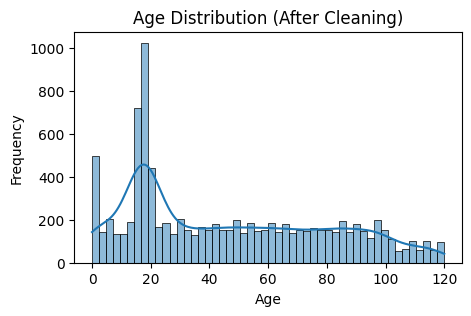

In [ ]:
#CLEANING NUMERICAL VARIABLES; AGE
#If age < 0 or age > 120 , set to NaN,
#If 150–199, treat as a missing decimal , divide by 10 (e.g., 173 , 17.3, 188 , 18.8)
#Impute remaining NaN with median
def clean_age(series, fix_missing_decimal=True, fill_unknown=True):
    s = pd.to_numeric(series, errors='coerce')
    if fix_missing_decimal:
        mask = (s >= 150) & (s < 200)   # e.g., 185 -> 18.5
        s.loc[mask] = s.loc[mask] / 10.0
    s.loc[(s < 0) | (s > 120)] = np.nan
    if fill_unknown:
        s = s.astype('object')
        s = s.where(s.notna(), 'Unknown')
    return s
df['Age'] = clean_age(df['Age'], fix_missing_decimal=True, fill_unknown=True)
#Visualize Age Distribution After cleaning
plt.figure(figsize=(5,3))
# Filter out 'Unknown' values before plotting
sns.histplot(df[df['Age'] != 'Unknown']['Age'].dropna(),bins=50,kde=True)
plt.title('Age Distribution (After Cleaning)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#CLEANING NUMERICAL VARIABLES; BLOOD PRESSURE
def clean_bp(x):
    if pd.isna(x):
        return np.nan, np.nan, np.nan
    s = str(x).strip().lower()
    s = s.replace('mmhg', '')
    s = re.sub(r'\s+', '', s)
    if s in {'high', 'hypertensive'}:
        return np.nan, np.nan, 1
    if '/' in s:
        try:
            sys, dia = map(float, s.split('/', 1))
            if dia > sys:
                sys, dia = dia, sys
            return sys, dia, np.nan
        except:
            return np.nan, np.nan, np.nan
    try:
        val = float(s)
        return val, np.nan, np.nan
    except:
        return np.nan, np.nan, np.nan
bp = df['Blood Pressure'].apply(clean_bp).apply(pd.Series)
bp.columns = ['Systolic_BP','Diastolic_BP','BP_High_Flag']
df[['Systolic_BP','Diastolic_BP','BP_High_Flag']] = bp
df.loc[(pd.to_numeric(df['Systolic_BP'], errors='coerce') < 60) |
       (pd.to_numeric(df['Systolic_BP'], errors='coerce') > 260), 'Systolic_BP'] = np.nan
df.loc[(pd.to_numeric(df['Diastolic_BP'], errors='coerce') < 30) |
       (pd.to_numeric(df['Diastolic_BP'], errors='coerce') > 150), 'Diastolic_BP'] = np.nan
num_sys = pd.to_numeric(df['Systolic_BP'], errors='coerce')
num_dia = pd.to_numeric(df['Diastolic_BP'], errors='coerce')
computed_high = ((num_sys >= 140) | (num_dia >= 90)).astype('float')  # 1.0/0.0 with NaN
df['BP_High_Flag'] = df['BP_High_Flag'].where(~df['BP_High_Flag'].isna(), computed_high)
for c in ['Systolic_BP','Diastolic_BP','BP_High_Flag']:
    df[c] = df[c].astype('object')
    df[c] = df[c].where(df[c].notna(), 'Unknown')
print(df['Systolic_BP'].unique())
print(df['Diastolic_BP'].unique())

[118.0 150.0 120.0 140.0 'Unknown' 200.0 130.0]
[78.0 90.0 80.0 'Unknown' 100.0 85.0]


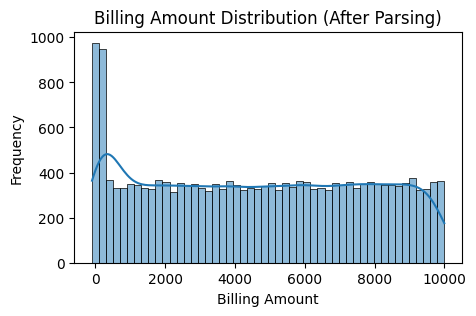

In [ ]:
#CLEANING NUMERICAL VARIABLES; BILLING AMOUNT
s = df['Billing Amount'].astype(str).str.strip()
s = s.replace(
    {'': np.nan, 'nan': np.nan, 'None': np.nan, 'N/A': np.nan, 'NA': np.nan, 'Unknown': np.nan},
    regex=False
)
s = s.str.replace(r'[\$,]', '', regex=True)
s = s.str.replace(r'^\(((.*)\))', r'-\1', regex=True)
num = pd.to_numeric(s, errors='coerce')
df['BillingAmount_clean'] = num.astype('object').where(num.notna(), 'Unknown')
#Visualize Billing Amount Distribution After cleaning
plt.figure(figsize=(5,3))
# Filter out 'Unknown' values before plotting
sns.histplot(df[df['BillingAmount_clean'] != 'Unknown']['BillingAmount_clean'].dropna(), bins=50, kde=True)
plt.title('Billing Amount Distribution (After Parsing)')
plt.xlabel('Billing Amount')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Cleaning Length of Stay
# 1) From dates (preferred)
adm = pd.to_datetime(df['Admission Date'], errors='coerce')
dis = pd.to_datetime(df['Discharge Date'], errors='coerce')
los_dates = (dis - adm).dt.days
los_dates = los_dates.mask(los_dates < 0, np.nan)
def parse_los(s):
    if pd.isna(s):
        return np.nan
    t = str(s).strip().lower()
    if t in {'', 'nan', 'none', 'null', 'missing', 'negative', 'unknown'}:
        return np.nan
    m = re.search(r'-?\d+', t)  # first integer (e.g., '5 days', '-4', '13')
    if not m:
        return np.nan
    val = int(m.group())
    return np.nan if val < 0 else val
los_text = df['Length of Stay'].apply(parse_los)
final_los = los_dates.fillna(los_text)
final_los = final_los.mask(final_los < 0, np.nan)
df['LOS_days'] = final_los.astype('object').where(final_los.notna(), 'Unknown')


LAST CHECK THEN IMPORT FILES

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Patient ID           20000 non-null  object  
 1   Age                  20000 non-null  object  
 2   Gender               20000 non-null  object  
 3   Date of Birth        20000 non-null  object  
 4   Diagnosis Code       20000 non-null  object  
 5   Procedure Code       20000 non-null  object  
 6   Admission Date       20000 non-null  object  
 7   Discharge Date       20000 non-null  object  
 8   Length of Stay       18360 non-null  object  
 9   Primary Diagnosis    20000 non-null  object  
 10  Medication Name      20000 non-null  object  
 11  Dosage               20000 non-null  object  
 12  Treatment Date       20000 non-null  object  
 13  Provider ID          20000 non-null  object  
 14  Hospital Name        20000 non-null  object  
 15  Insurance Type       200

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive"
out_path = f"{save_dir}/cleaned_dataset_{datetime.now():%Y%m%d_%H%M%S}.xlsx"
with pd.ExcelWriter(out_path, engine="xlsxwriter", datetime_format="yyyy-mm-dd") as w:
    df.to_excel(w, index=False, sheet_name="cleaned")
print("Saved to Drive:", out_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive: /content/drive/MyDrive/cleaned_dataset_20251013_120612.xlsx
